
# Hamiltonian Variational Ansatz for the Transverse-Field Ising Model with $\mathfrak{g}$-sim

This notebook demonstrates how to build and evaluate the free-fermionic TFIM benchmark used in the manuscript. The problem is the one-dimensional transverse-field Ising model (TFIM) on a path graph (i.e., with open boundary conditions),

$$
H_{\mathrm{TFIM}}
=
\sum_{i=0}^{n-2} Z_i Z_{i+1}
-
g \sum_{i=0}^{n-1} X_i,
$$

together with a freely-parameterized Hamiltonian variational ansatz (HVA). The generator set is

$$
G_{\mathrm{TFIM}}^{\mathrm{free}}
=
\{Z_i Z_{i+1}\}_{i=0}^{n-2}
\cup
\{X_i\}_{i=0}^{n-1},
$$

and one layer applies one independent parameter to every generator. In the ordering used by the helper code, each layer is

$$
U_\ell(\boldsymbol\theta_\ell)
=
\left(\prod_{i=0}^{n-1} e^{-i \beta_{\ell,i} X_i}\right)
\left(\prod_{i=0}^{n-2} e^{-i \gamma_{\ell,i} Z_i Z_{i+1}}\right),
$$

so the full circuit is
$$
U(\boldsymbol\theta)=\prod_{\ell=1}^{L} U_\ell(\boldsymbol\theta_\ell).
$$

For open boundaries, the associated free-fermion DLA has dimension

$$
\dim(\mathfrak g)=n(2n-1),
$$

and in the manuscript the overparameterized choice is obtained by taking \(L=n\), so that

$$
N_{\mathrm{params}}=(2n-1)L=\dim(\mathfrak g).
$$

We use the product input state $|+\rangle^{\otimes n}$ and take the TFIM Hamiltonian itself as the measurement operator, so the notebook evaluates the TFIM energy landscape exactly as in the paper's free-fermion numerical example.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from tfim_simulator import simulator_functions
from tfim_helpers import get_TFIM_ground_state_energy


## 1. Define a small demonstration problem

For the manuscript experiment, the practically relevant overparameterized choice is \(L=n\). We keep the same choice here, but use a deliberately small system size so that a direct Hilbert-space reference simulation remains cheap.

The most important convention to keep in mind is the parameter ordering:

- all single-qubit \(X\) angles for layer \(0\),
- then all nearest-neighbor \(ZZ\) angles for layer \(0\),
- then the same pattern for layer \(1\), and so on.

This is precisely the convention used internally by `tfim_simulator.simulator_functions(...)`.


In [2]:
# Problem specification
SIZE = 6
LAYERS = SIZE
G_VALUE = 0.5
BOUNDS = "open"
SEED = 0

NUM_X = SIZE
NUM_ZZ = SIZE - 1 if BOUNDS == "open" else SIZE
NUM_PARAMS = (NUM_X + NUM_ZZ) * LAYERS

rng = np.random.default_rng(SEED)
thetas0 = rng.uniform(-np.pi, np.pi, NUM_PARAMS)

print(f"system size n = {SIZE}")
print(f"layers L = {LAYERS}")
print(f"number of parameters = {NUM_PARAMS}")

system size n = 6
layers L = 6
number of parameters = 66



## 2. Build the $\mathfrak{g}$-sim loss function

The helper `simulator_functions(...)` performs the Lie-closure preprocessing for the TFIM generators, constructs the input expectation vector for $|+\rangle^{\otimes n}$, and returns a callable that evaluates the energy expectation value in adjoint space.

For the free TFIM-HVA used here, the observable is the TFIM Hamiltonian itself, so the returned function directly evaluates the variational energy.


In [3]:
loss_gsim = simulator_functions(
    SIZE,
    LAYERS,
    G_VALUE,
    rho="plus",
    bounds=BOUNDS,
    return_grad=False,
)

print("g-sim loss at a random parameter point:")
print(loss_gsim(thetas0))

g-sim loss at a random parameter point:
0.07510897172048236



## 3. Reference circuit simulation

To validate the reduced-space result, we now build the same TFIM-HVA loss directly on a circuit simulator.

For this we initialize the circuit in a $|+\rangle^{\otimes n}$ state by applying one layer of Hadamards followed by
- one freely parametrized $X$ rotation layer
- one freely parametrized $ZZ$ rotation layer.


In [4]:
import tequila as tq

def loss_reference(thetas):
    # generate HVA ansatz circuit
    U = tq.QCircuit()
    U += tq.gates.H(np.arange(SIZE)) # such that rho_in is plus state
    for l in range(LAYERS):
        for i in range(SIZE):
            U += tq.gates.Rx(2*tq.Variable(f"beta{l}_{i}"), i)
        for i in range(SIZE - 1):
            U += tq.gates.ExpPauli(tq.PauliString({int(i): "Z", int(i+1): "Z"}), angle=2 * tq.Variable(f"gamma{l}_{i}"))
        if BOUNDS == 'periodic':
            U += tq.gates.ExpPauli(tq.PauliString({int(SIZE-1): "Z", int(0): "Z"}), angle=2 * tq.Variable(f"gamma{l}_{SIZE-1}"))

    # generate TFIM measurement operator
    paulis = []
    for i in range(SIZE):
        paulis.append(tq.PauliString({int(i): "X"}, -G_VALUE))
    for i in range(SIZE-1):
        paulis.append(tq.PauliString({int(i): "Z", int(i+1): "Z"}, 1))
    if BOUNDS == 'periodic':
        paulis.append(tq.PauliString({int(SIZE-1): "Z", int(0): "Z"}, 1))

    H = tq.QubitHamiltonian.from_paulistrings(paulis)

    # define expectation value
    E = tq.ExpectationValue(U, H)

    vars = U.extract_variables()
    init = {var: theta for var, theta in zip(vars, thetas)}

    return tq.simulate(E, init)


## 4. Pointwise verification

At a fixed parameter point, the direct state-vector simulation and the reduced adjoint-space simulation should agree up to numerical precision.


In [5]:
ref_val = loss_reference(thetas0)
gsim_val = loss_gsim(thetas0)
E0_exact = get_TFIM_ground_state_energy(SIZE, g=G_VALUE)

print("reference loss:", ref_val)
print("g-sim loss:   ", gsim_val)
print("allclose?     ", np.allclose(ref_val, gsim_val))
print("abs. error:   ", abs(ref_val - gsim_val))
print("exact ground energy E0:", E0_exact)

reference loss: 0.07510901407991183
g-sim loss:    0.07510897172048236
allclose?      True
abs. error:    4.235942946406723e-08
exact ground energy E0: -5.522029570800219



## 5. One-dimensional loss slice

A simple but very instructive diagnostic is to vary a single parameter while keeping all others fixed. The plot below compares the direct state-vector simulation and the reduced adjoint-space simulation along such a one-dimensional slice. Matching curves confirm that the `g`-sim implementation reproduces the same TFIM-HVA energy landscape while working in the polynomially sized Lie-algebra representation.

We vary the last parameter, corresponding to the last \(ZZ\)-rotation in the last layer, and keep all remaining angles fixed at the random base point `thetas0`.


In [6]:
from tqdm import tqdm

scan = np.linspace(-np.pi, np.pi, 121)
losses_gsim = []
losses_ref = []

for x in tqdm(scan):
    thetas = thetas0.copy()
    thetas[-1] = x
    losses_gsim.append(loss_gsim(thetas))
    losses_ref.append(loss_reference(thetas))

losses_gsim = np.array(losses_gsim)
losses_ref = np.array(losses_ref)

100%|██████████| 121/121 [00:01<00:00, 62.31it/s]


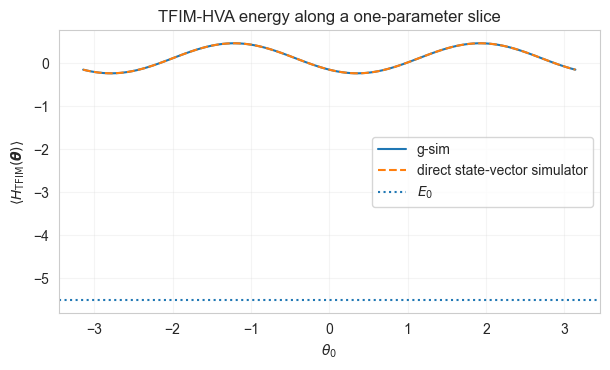

max |difference| along the slice: 1.6539400576887076e-07


In [7]:
plt.figure(figsize=(6.2, 3.8))
plt.plot(scan, losses_gsim, label="g-sim")
plt.plot(scan, losses_ref, "--", label="direct state-vector simulator")
plt.axhline(E0_exact, linestyle=":", label=r"$E_0$")
plt.xlabel(r"$\theta_{0}$")
plt.ylabel(r"$\langle H_{\mathrm{TFIM}}(\boldsymbol{\theta}) \rangle$")
plt.title("TFIM-HVA energy along a one-parameter slice")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print("max |difference| along the slice:", np.max(np.abs(losses_gsim - losses_ref)))

## 6. Remarks

- The notebook demonstrates the same reduced-space TFIM energy evaluation used in the manuscript's free-fermion numerical example, but on a deliberately small instance suitable for interactive execution.
- In the large-scale study, the same $\mathfrak{g}$-sim machinery is used up to much larger system sizes, while the exact ground-state energy is obtained from free-fermion diagonalization only as a reference.
- The present implementation is intentionally problem-specific: it uses the freely-parameterized TFIM generator set with one parameter per individual $X$ and $ZZ$ gate. This is exactly the regime where the manuscript exploits the quadratic DLA dimension $\dim(\mathfrak g)=n(2n-1)$ for open chains.
- If desired, the same helper `simulator_functions(...)` can also return gradients by setting `return_grad=True`.
